# Notebook 4: Evaluation And Model Comparison

This notebook evaluates YOLOv8 and Faster R-CNN on the shared test split and compares mAP and IoU metrics.

In [ ]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00


In [ ]:
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader
from torchmetrics.detection import MeanAveragePrecision
from ultralytics import YOLO


def resolve_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "medical_detection").exists():
            return candidate

    kaggle_candidate = Path("/kaggle/working/model-comparison-for-lesion-detection")
    if (kaggle_candidate / "medical_detection").exists():
        return kaggle_candidate

    raise FileNotFoundError("Could not locate a project root containing the medical_detection package.")


def resolve_split_label(split_suffix: str) -> str:
    return split_suffix.lstrip("_") or "baseline"


def find_yolo_weights_for_split(project_root: Path, split_label: str) -> Path:
    detect_dir = project_root / "runs" / "detect"
    if split_label == "baseline":
        helper_path = detect_dir / "latest_yolo_run.txt"
        if helper_path.exists():
            run_dir = Path(helper_path.read_text(encoding="utf-8").strip())
            candidate = run_dir / "weights" / "best.pt"
            if candidate.exists():
                return candidate
    candidates = sorted(
        detect_dir.glob(f"*{split_label}*/weights/best.pt"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(f"No YOLO best.pt file found for split label '{split_label}' under {detect_dir}")
    return candidates[0]


def find_frcnn_checkpoint_for_split(project_root: Path, split_label: str) -> Path:
    checkpoint_dir = project_root / "runs" / ("frcnn" if split_label == "baseline" else f"frcnn_{split_label}")
    preferred = checkpoint_dir / "faster_rcnn_best.pth"
    if preferred.exists():
        return preferred
    candidates = sorted(checkpoint_dir.glob("*.pth"), key=lambda path: path.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No Faster R-CNN checkpoint found under {checkpoint_dir}")
    return candidates[0]


PROJECT_ROOT = resolve_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from medical_detection import (
    FRCNNDataset,
    FRCNNDatasetConfig,
    ProjectPaths,
    build_dataset_index,
    build_faster_rcnn_model,
    class_names_from_csv,
    collate_fn,
    compute_detection_match_summary,
    convert_yolo_to_xyxy,
    load_split_filenames,
    materialize_yolo_dataset,
    records_from_filenames,
    resolve_dataset_root,
    summarize_detection_rows,
    write_yolo_data_yaml,
)
from medical_detection.frcnn_dataset import build_image_transform

DATASET_ROOT = resolve_dataset_root(PROJECT_ROOT)
paths = ProjectPaths(project_root=PROJECT_ROOT, dataset_root=DATASET_ROOT)
class_names = class_names_from_csv(paths.csv_path)
nc = len(class_names)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
YOLO_SPLIT_SUFFIX = "" # _bg15
FRCNN_SPLIT_SUFFIX = ""
YOLO_SPLIT_LABEL = resolve_split_label(YOLO_SPLIT_SUFFIX)
FRCNN_SPLIT_LABEL = resolve_split_label(FRCNN_SPLIT_SUFFIX)
YOLO_WORKING_DIR = paths.project_root / f"yolo_dataset_{YOLO_SPLIT_LABEL}"
YOLO_DATA_YAML = paths.project_root / f"data_live_{YOLO_SPLIT_LABEL}.yaml"
YOLO_CUSTOM_THRESHOLD = 0.05
FRCNN_CUSTOM_THRESHOLD = 0.05
MATCH_IOU_THRESHOLD = 0.5

print("Evaluation device:", device)
print(f"PROJECT_ROOT: {paths.project_root}")
print(f"DATASET_ROOT: {paths.dataset_root}")
print(f"YOLO split variant: {YOLO_SPLIT_LABEL}")
print(f"Faster R-CNN split variant: {FRCNN_SPLIT_LABEL}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO evaluation device: 0


In [ ]:
dataset_index = build_dataset_index(paths.image_dir, paths.label_dir, paths.csv_path, group_size=25)
class_mapping = {index: name for index, name in enumerate(class_names)}


def get_record_for_path(image_path):
    return dataset_index.by_filename[Path(image_path).name]


def get_ground_truth(image_path, include_background_offset=False):
    record = get_record_for_path(image_path)
    with Image.open(record.image_path) as image_handle:
        image_width, image_height = image_handle.size
    boxes = []
    labels = []
    label_names = []
    for ann in record.annotations:
        box = convert_yolo_to_xyxy(ann.x_center, ann.y_center, ann.width, ann.height, image_width, image_height)
        boxes.append([box.xmin, box.ymin, box.xmax, box.ymax])
        label_value = ann.class_id + 1 if include_background_offset else ann.class_id
        labels.append(label_value)
        label_names.append(class_names[ann.class_id])
    if boxes:
        box_tensor = torch.tensor(boxes, dtype=torch.float32)
        label_tensor = torch.tensor(labels, dtype=torch.int64)
    else:
        box_tensor = torch.zeros((0, 4), dtype=torch.float32)
        label_tensor = torch.zeros((0,), dtype=torch.int64)
    return box_tensor, label_tensor, label_names

In [ ]:
materialize_yolo_dataset(
    splits_dir=paths.splits_dir,
    image_dir=paths.image_dir,
    label_dir=paths.label_dir,
    output_dir=YOLO_WORKING_DIR,
    split_suffix=YOLO_SPLIT_SUFFIX,
 )
YOLO_DATA_YAML = write_yolo_data_yaml(YOLO_WORKING_DIR, class_names, YOLO_DATA_YAML)
test_records = records_from_filenames(dataset_index, load_split_filenames(paths.splits_dir / f"test{YOLO_SPLIT_SUFFIX}.txt"))
test_image_paths = [str(record.image_path) for record in test_records]
print(f"Prepared {len(test_image_paths)} test images for YOLO split {YOLO_SPLIT_LABEL}")
print(f"YOLO data YAML: {YOLO_DATA_YAML}")

Linking train set...
Linking val set...
Linking test set...


In [ ]:
print(class_names)
print(class_mapping)

Created live config at /kaggle/working/data_live.yaml


In [ ]:
YOLO_WEIGHTS_PATH = find_yolo_weights_for_split(paths.project_root, YOLO_SPLIT_LABEL)
print("Using YOLO weights:")
print(YOLO_WEIGHTS_PATH)

yolo_model = YOLO(str(YOLO_WEIGHTS_PATH))
yolo_eval = yolo_model.val(data=str(YOLO_DATA_YAML), split="test")

yolo_match_rows = []
for image_path in test_image_paths:
    gt_boxes, gt_labels, _ = get_ground_truth(image_path, include_background_offset=False)
    prediction = yolo_model.predict(source=image_path, conf=YOLO_CUSTOM_THRESHOLD, verbose=False, device=(0 if torch.cuda.is_available() else "cpu"))[0]
    if prediction.boxes is not None and len(prediction.boxes) > 0:
        pred_boxes = prediction.boxes.xyxy.cpu()
        pred_labels = prediction.boxes.cls.cpu().to(torch.int64)
    else:
        pred_boxes = torch.zeros((0, 4), dtype=torch.float32)
        pred_labels = torch.zeros((0,), dtype=torch.int64)
    summary = compute_detection_match_summary(pred_boxes, pred_labels, gt_boxes, gt_labels, iou_threshold=MATCH_IOU_THRESHOLD)
    yolo_match_rows.append(summary)

yolo_iou_summary = summarize_detection_rows(yolo_match_rows)
print(yolo_iou_summary)

YOLO helper file not available. Using newest weights by modification time.
Using latest YOLO weights:
/kaggle/input/notebooks/zvonimirstaubringer/02-yolov8-training/runs/detect/train/weights/best.pt
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±1.2 ms, read: 11.1±5.0 MB/s, size: 61.5 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/test... 1849 images, 628 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1849/1849 324.7it/s 5.7s
val: New cache created: /kaggle/working/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 116/116 7.8it/s 14.9s
                   all       1849       2311      0.639       0.52       0.55      0.328
        angiodysplasia         78         88      0.494      0.466      0.455      0.229
               erosion        439    

In [ ]:
frcnn_inference_transform = build_image_transform(train=False)
frcnn_test_records = records_from_filenames(dataset_index, load_split_filenames(paths.splits_dir / f"test{FRCNN_SPLIT_SUFFIX}.txt"))
test_dataset_frcnn = FRCNNDataset(frcnn_test_records, FRCNNDatasetConfig(include_empty_images=True, train=False))
test_dataloader_frcnn = DataLoader(test_dataset_frcnn, batch_size=2 if torch.cuda.is_available() else 1, shuffle=False, num_workers=0, collate_fn=collate_fn)

frcnn_checkpoint_path = find_frcnn_checkpoint_for_split(paths.project_root, FRCNN_SPLIT_LABEL)
frcnn_model = build_faster_rcnn_model(num_classes=nc + 1, pretrained=False)
frcnn_model.load_state_dict(torch.load(frcnn_checkpoint_path, map_location=device)["model_state_dict"])
frcnn_model.to(device)
frcnn_model.eval()
print("Loaded Faster R-CNN checkpoint:")
print(frcnn_checkpoint_path)
print(f"Test dataset size: {len(test_dataset_frcnn)} for split {FRCNN_SPLIT_LABEL}")

Loaded 1849 images for test
1849


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 198MB/s]


Loading checkpoint from /kaggle/input/datasets/zvonimirstaubringer/fasterrcnn-first-training/runs/frcnn/faster_rcnn_best.pth
Loaded Faster R-CNN checkpoint:
/kaggle/input/datasets/zvonimirstaubringer/fasterrcnn-first-training/runs/frcnn/faster_rcnn_best.pth


In [ ]:
metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
frcnn_match_rows = []

with torch.no_grad():
    for images, targets in test_dataloader_frcnn:
        images_on_device = [image.to(device) for image in images]
        outputs = frcnn_model(images_on_device)
        preds = []
        refs = []
        for output, target in zip(outputs, targets):
            preds.append(
                {
                    "boxes": output["boxes"].cpu(),
                    "scores": output["scores"].cpu(),
                    "labels": output["labels"].cpu(),
                }
            )
            refs.append({"boxes": target["boxes"].cpu(), "labels": target["labels"].cpu()})

            score_mask = output["scores"].cpu() >= FRCNN_CUSTOM_THRESHOLD
            filtered_boxes = output["boxes"].cpu()[score_mask]
            filtered_labels = output["labels"].cpu()[score_mask]
            summary = compute_detection_match_summary(
                filtered_boxes,
                filtered_labels,
                target["boxes"].cpu(),
                target["labels"].cpu(),
                iou_threshold=MATCH_IOU_THRESHOLD,
            )
            frcnn_match_rows.append(summary)
        metric.update(preds, refs)

frcnn_eval = metric.compute()
frcnn_iou_summary = summarize_detection_rows(frcnn_match_rows)
print(frcnn_iou_summary)

{'dataset_mean_matched_iou': 0.45381046000181235, 'dataset_mean_best_iou_per_gt': 0.45213193941902696, 'dataset_mean_best_iou_per_pred': 0.23026201196252621}


In [ ]:
comparison_rows = [
    {
        "model": "YOLOv8",
        "mAP@0.5": float(yolo_eval.box.map50),
        "mAP@0.5:0.95": float(yolo_eval.box.map),
        "mean_matched_IoU": float(yolo_iou_summary["dataset_mean_matched_iou"]),
        "mean_best_IoU_per_GT": float(yolo_iou_summary["dataset_mean_best_iou_per_gt"]),
        "mean_best_IoU_per_pred": float(yolo_iou_summary["dataset_mean_best_iou_per_pred"]),
    },
    {
        "model": "Faster R-CNN",
        "mAP@0.5": float(frcnn_eval["map_50"].item()),
        "mAP@0.5:0.95": float(frcnn_eval["map"].item()),
        "mean_matched_IoU": float(frcnn_iou_summary["dataset_mean_matched_iou"]),
        "mean_best_IoU_per_GT": float(frcnn_iou_summary["dataset_mean_best_iou_per_gt"]),
        "mean_best_IoU_per_pred": float(frcnn_iou_summary["dataset_mean_best_iou_per_pred"]),
    },
]
comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

metrics_dir = paths.runs_dir / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(metrics_dir / "model_comparison_summary.csv", index=False)
(metrics_dir / "model_comparison_summary.json").write_text(json.dumps(comparison_rows, indent=2), encoding="utf-8")
print(f"Saved comparison metrics to {metrics_dir}")

       model  mAP@0.5  mAP@0.5:0.95  mean_matched_IoU  mean_best_IoU_per_GT  mean_best_IoU_per_pred
      YOLOv8 0.549958       0.32835          0.523204              0.523186                0.196554
Faster R-CNN 0.396691       0.18222          0.453810              0.452132                0.230262


## Qualitative Bounding Box Comparison

The next cell visualizes ground-truth boxes, YOLOv8 predictions, and Faster R-CNN predictions on at least 5 test images.


In [ ]:
print(class_names)
print(class_mapping)

['angiodysplasia', 'erosion', 'stenosis', 'lymphangiectasia', 'lymph follicle', 'SMT', 'polyp-like', 'bleeding', 'diverticulum', 'erythema', 'foreign body', 'vein']
{0: 'angiodysplasia', 1: 'erosion', 2: 'stenosis', 3: 'lymphangiectasia', 4: 'lymph follicle', 5: 'SMT', 6: 'polyp-like', 7: 'bleeding', 8: 'diverticulum', 9: 'erythema', 10: 'foreign body', 11: 'vein'}


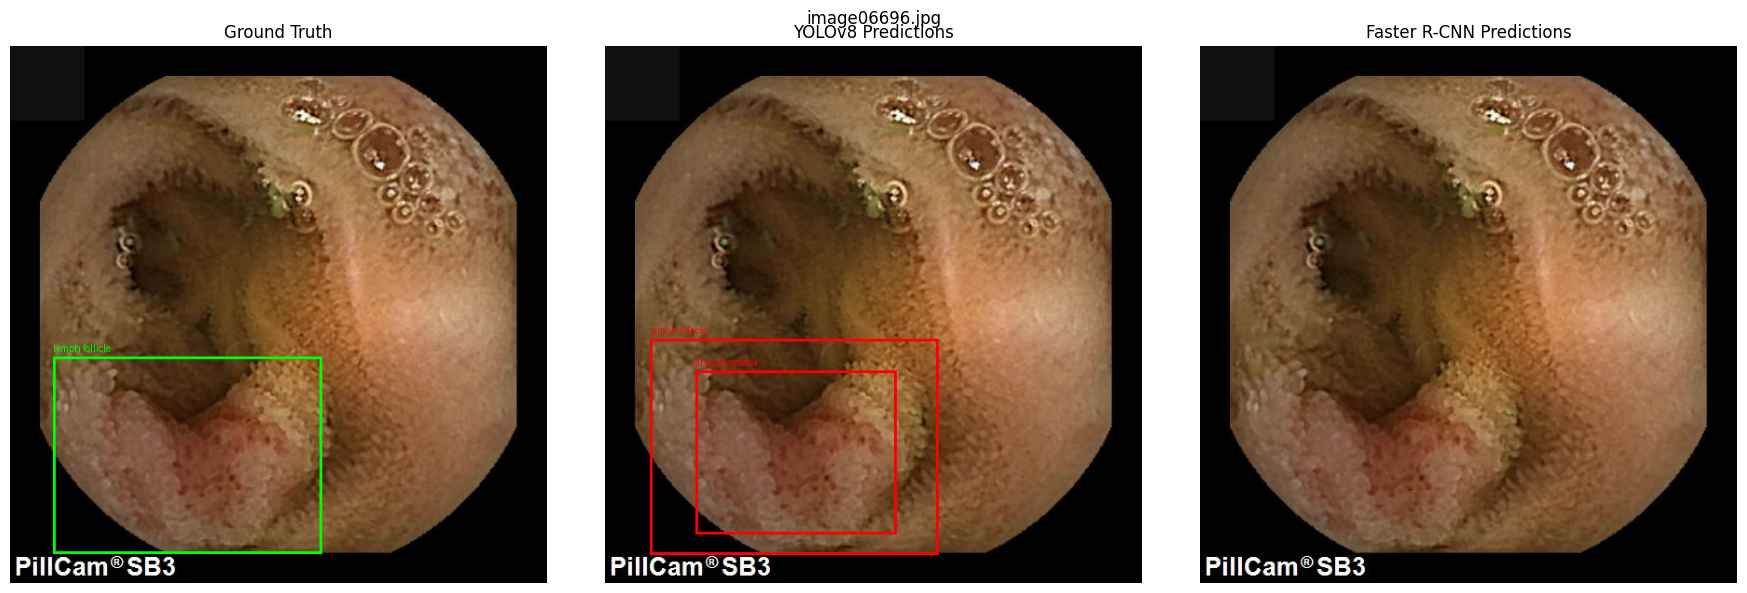

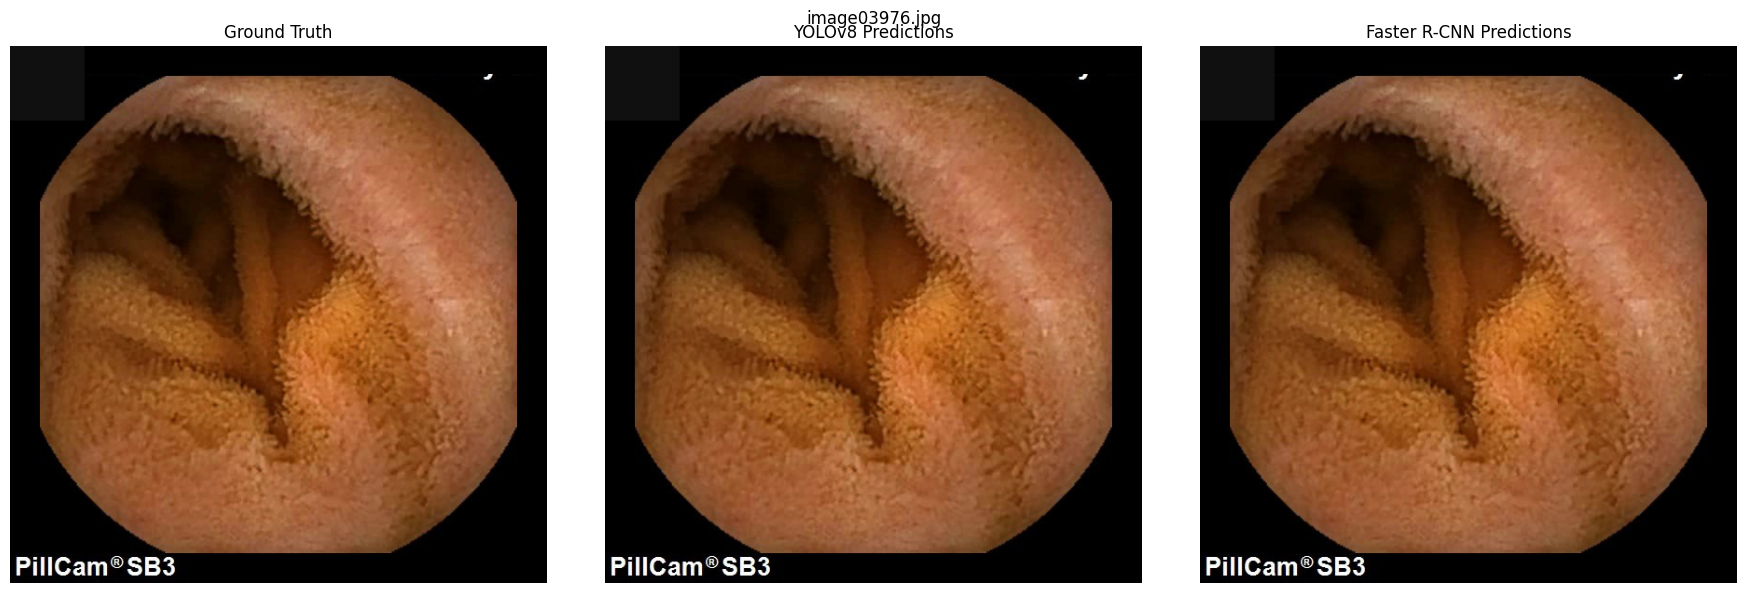

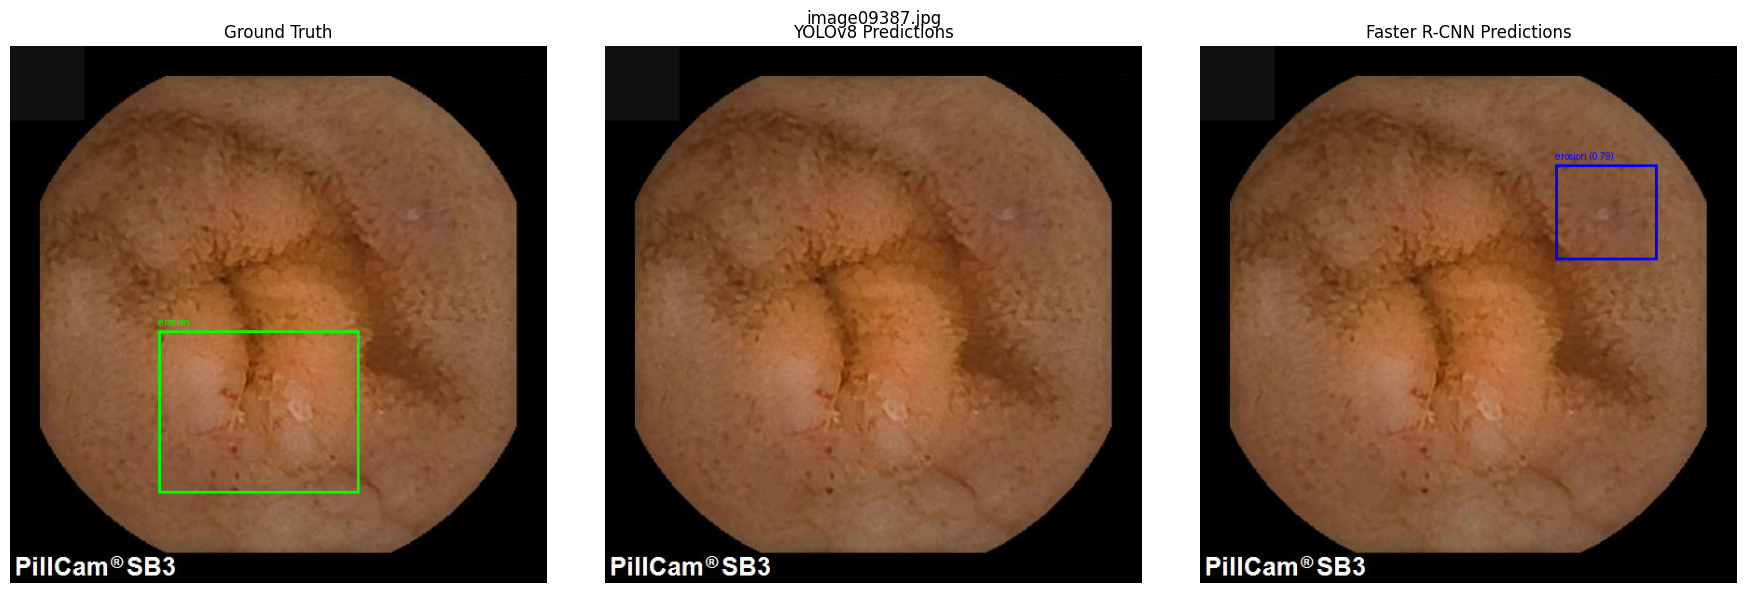

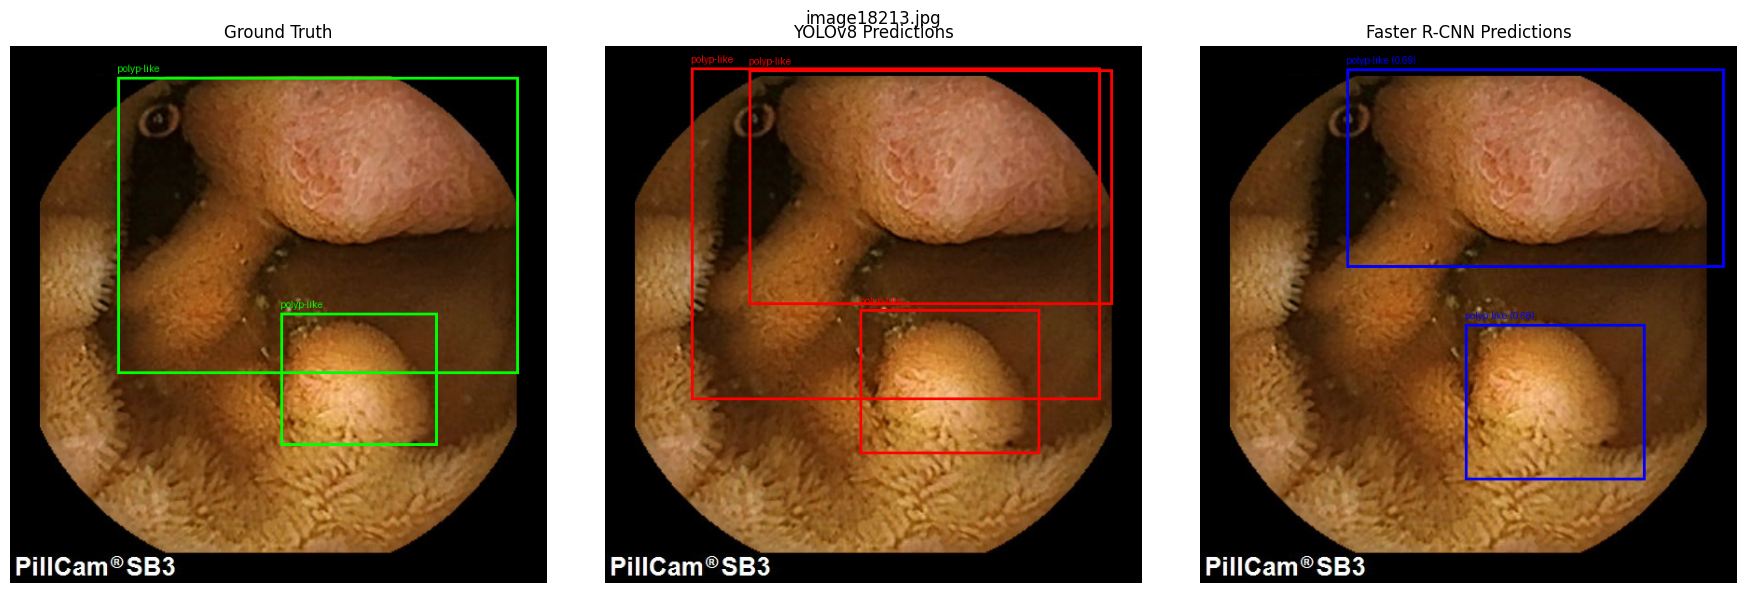

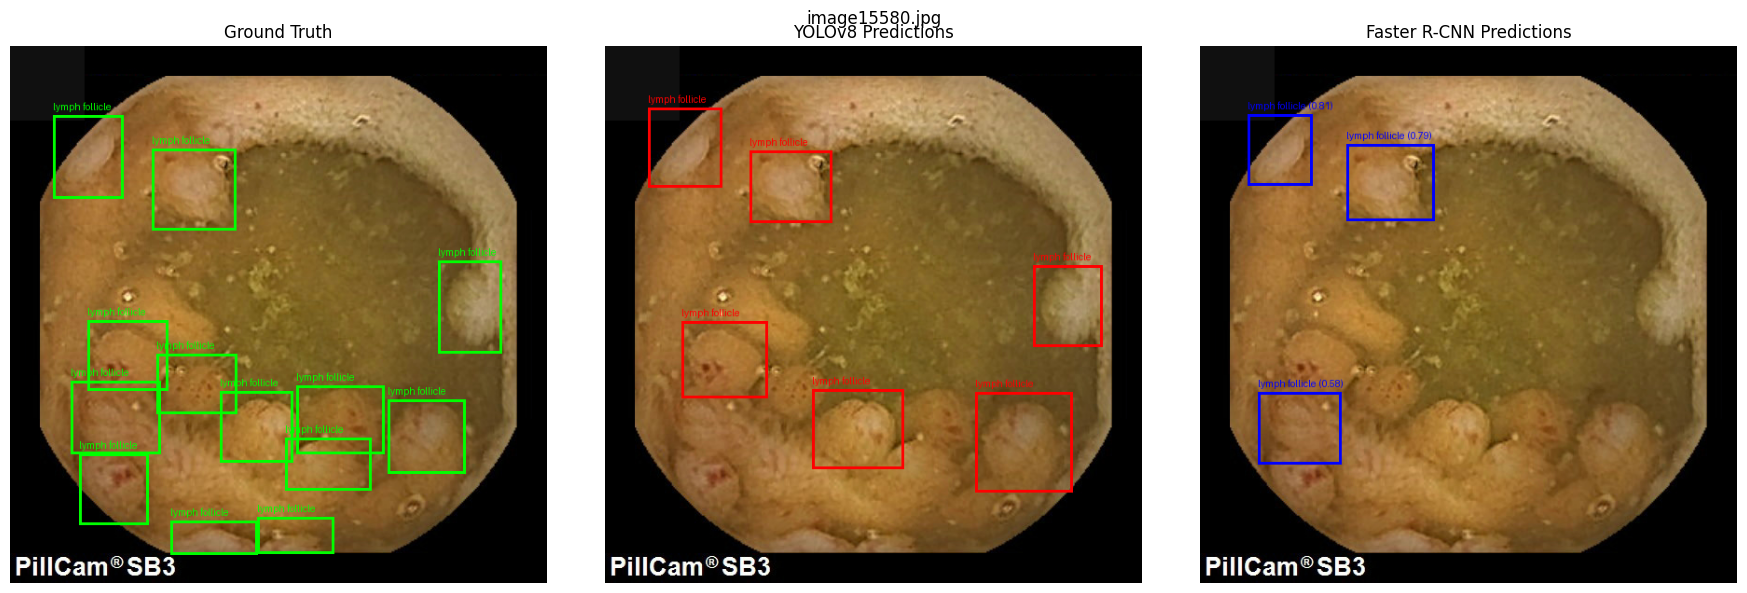

In [ ]:
def draw_boxes_on_image(image, boxes, labels=None, color="red", width=3):
    draw = ImageDraw.Draw(image)
    for index, box in enumerate(boxes):
        xmin, ymin, xmax, ymax = [int(value) for value in box]
        draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=width)
        if labels is not None and index < len(labels):
            draw.text((xmin, max(0, ymin - 15)), str(labels[index]), fill=color)
    return image


def get_yolo_prediction_boxes_and_labels(image_path, score_threshold=0.25):
    prediction = yolo_model.predict(source=image_path, conf=score_threshold, verbose=False, device=(0 if torch.cuda.is_available() else "cpu"))[0]
    boxes = prediction.boxes.xyxy.cpu().tolist() if prediction.boxes is not None else []
    labels = [class_names[int(cls)] for cls in prediction.boxes.cls.cpu().tolist()] if prediction.boxes is not None else []
    return boxes, labels


def get_frcnn_prediction_boxes_and_labels(image_path, score_threshold=0.5):
    image = Image.open(image_path).convert("RGB")
    tensor = frcnn_inference_transform(image).to(device)
    with torch.no_grad():
        output = frcnn_model([tensor])[0]

    boxes = []
    labels = []
    for box, class_id, score in zip(output["boxes"].cpu().tolist(), output["labels"].cpu().tolist(), output["scores"].cpu().tolist()):
        if score < score_threshold:
            continue
        boxes.append(box)
        class_index = class_id - 1
        class_name = class_names[class_index] if 0 <= class_index < len(class_names) else f"class_{class_id}"
        labels.append(f"{class_name} ({score:.2f})")
    return boxes, labels


visualization_paths = random.sample(test_image_paths, min(5, len(test_image_paths)))
for image_path in visualization_paths:
    original_image = Image.open(image_path).convert("RGB")
    gt_boxes, _, gt_labels = get_ground_truth(image_path, include_background_offset=False)
    yolo_boxes, yolo_labels = get_yolo_prediction_boxes_and_labels(image_path)
    frcnn_boxes, frcnn_labels = get_frcnn_prediction_boxes_and_labels(image_path)

    gt_image = draw_boxes_on_image(original_image.copy(), gt_boxes.tolist(), gt_labels, color="lime", width=3)
    yolo_image = draw_boxes_on_image(original_image.copy(), yolo_boxes, yolo_labels, color="red", width=3)
    frcnn_image = draw_boxes_on_image(original_image.copy(), frcnn_boxes, frcnn_labels, color="blue", width=3)

    plt.figure(figsize=(18, 6))
    plt.suptitle(Path(image_path).name)
    plt.subplot(1, 3, 1)
    plt.imshow(gt_image)
    plt.axis("off")
    plt.title("Ground Truth")

    plt.subplot(1, 3, 2)
    plt.imshow(yolo_image)
    plt.axis("off")
    plt.title("YOLOv8 Predictions")

    plt.subplot(1, 3, 3)
    plt.imshow(frcnn_image)
    plt.axis("off")
    plt.title("Faster R-CNN Predictions")

    plt.tight_layout()
    plt.show()